In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
spotify = pd.read_csv("/content/spotify_cleaned.csv")
spotify

,Position,Artist Name,Song Name,Days Since Released,Top 10 (xTimes),Peak Position,Peak Position (xTimes),Peak Streams,Total Streams
0,1,Post Malone,Sunflower SpiderMan: Into the SpiderVerse,1506,302,1,(x29),2118242,883369738
1,2,Juice WRLD,Lucid Dreams,1673,178,1,(x20),2127668,864832399
2,3,Lil Uzi Vert,XO TOUR Llif3,1853,212,1,(x4),1660502,781153024
3,4,J. Cole,No Role Modelz,2547,6,7,0,659366,734857487
4,5,Post Malone,rockstar,1223,186,1,(x124),2905678,718865961
...,...,...,...,...,...,...,...,...,...
11079,11080,The Band Perry,If I Die Young,1,0,184,0,51321,51321
11080,11081,Justin Timberlake,Not a Bad Thing,1,0,196,0,49512,49512
11081,11082,Mike WiLL Made,It 23,1,0,167,0,46547,46547
11082,11083,The Vamps,Somebody To You,1,0,200,0,44962,44962


In [ ]:
x = spotify[["Peak Streams", "Days Since Released"]]
y = spotify["Total Streams"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model1 = LinearRegression()
model1.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_test_pred = model1.predict(x_test)
y_train_pred = model1.predict(x_train)

In [ ]:
print("Model 1 Training R2:", r2_score(y_train, y_train_pred))
print("Model 1 Test R2:", r2_score(y_test, y_test_pred))
print("Model 1 Test MSE:", mean_squared_error(y_test, y_test_pred))

Model 1 Training R2: 0.8865304341117541
Model 1 Test R2: 0.8983652126647987
Model 1 Test MSE: 341470479902331.7


In [ ]:
spotify.rename(columns={"Peak Streams": "peak_streams", "Days Since Released":"days_since_released", "Total Streams": "total_streams", "Top 10 (xTimes)" : "top_10_freq"}, inplace=True)


In [ ]:

linear_model_1 = smf.ols("total_streams ~ days_since_released + peak_streams", data = spotify).fit()
linear_model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          total_streams   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                 4.461e+04
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        19:01:01   Log-Likelihood:            -2.0049e+05
No. Observations:               11084   AIC:                         4.010e+05
Df Residuals:                   11081   BIC:                         4.010e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -8.591e+06   2.21e+05    -38.895      0.000   -9.02e+06   -8.16e+06
days_since_released  3.513e+05   1334.986    263.137      0.000    3.49e+05    3.54e+05
peak_streams           14.7451      0.276     53.484      0.000      14.205      15.285
==============================================================================
Omnibus:                     8570.561   Durbin-Watson:                   1.238
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1612415.009
Skew:                           2.829   Prob(JB):                         0.00
Kurtosis:                      61.816   Cond. No.                     1.12e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.12e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: >

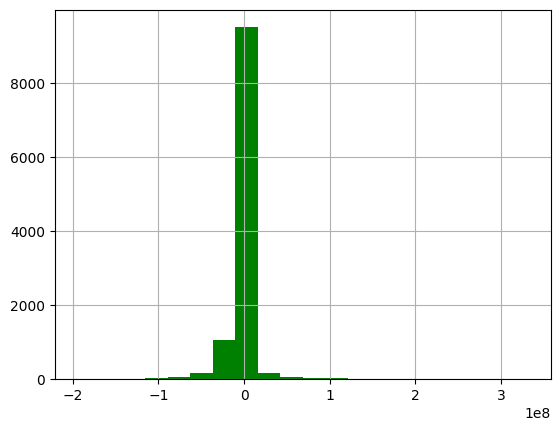

In [ ]:
linear_model_1.resid.hist(bins=20, color="green")

Text(0, 0.5, 'Residuals')

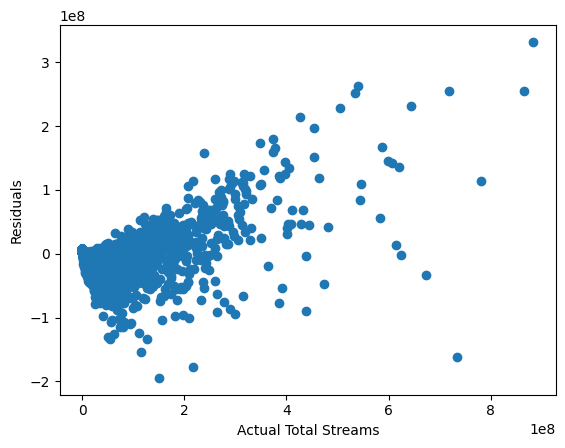

In [ ]:
plt.scatter(x = spotify["total_streams"], y = linear_model_1.resid)
plt.xlabel("Actual Total Streams")
plt.ylabel("Residuals")

In [ ]:
spotify

In [ ]:
x2 = spotify[["peak_streams", "top_10_freq"]]

In [ ]:
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y, test_size=0.2, random_state=42)

In [ ]:
model2 = LinearRegression()
model2.fit(x2_train,y2_train)

LinearRegression()

In [ ]:
y2_test_pred = model2.predict(x2_test)
y2_train_pred = model2.predict(x2_train)

In [ ]:
print("Model 2 Training R2:", r2_score(y2_train, y2_train_pred))
print("Model 2 Test R2:", r2_score(y2_test, y2_test_pred))
print("Model 2 Test MSE:", mean_squared_error(y2_test, y2_test_pred))

Model 2 Training R2: 0.5711234223759349
Model 2 Test R2: 0.5833147213608053
Model 2 Test MSE: 1399970677322230.0


In [ ]:
linear_model_2 = smf.ols("total_streams ~ top_10_freq + peak_streams", data = spotify).fit()
linear_model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          total_streams   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     7487.
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        19:21:24   Log-Likelihood:            -2.0796e+05
No. Observations:               11084   AIC:                         4.159e+05
Df Residuals:                   11081   BIC:                         4.159e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     3.552e+06   4.35e+05      8.173      0.000     2.7e+06     4.4e+06
top_10_freq   2.222e+06   2.25e+04     98.924      0.000    2.18e+06    2.27e+06
peak_streams    15.7833      0.558     28.295      0.000      14.690      16.877
==============================================================================
Omnibus:                    12479.408   Durbin-Watson:                   1.068
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          2150294.949
Skew:                           5.600   Prob(JB):                         0.00
Kurtosis:                      70.309   Cond. No.                     1.13e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: >

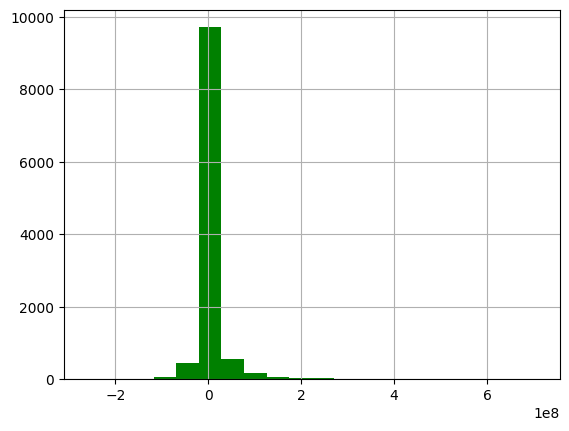

In [ ]:
linear_model_2.resid.hist(bins=20, color="green")

Text(0, 0.5, 'Residuals')

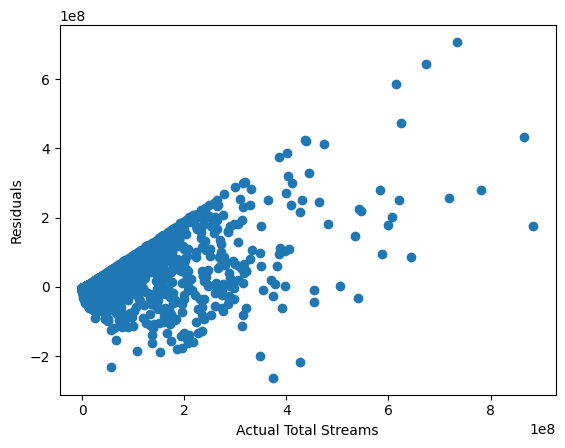

In [ ]:
plt.scatter(x = spotify["total_streams"], y = linear_model_2.resid)
plt.xlabel("Actual Total Streams")
plt.ylabel("Residuals")